In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)

In [2]:
X, y = mnist.data, mnist.target

In [3]:
y[:2]

array(['5', '0'], dtype=object)

In [4]:
X.shape

(70000, 784)

In [5]:
y.shape

(70000,)

There are 70000 images and each image has 784 features. Note that $784 = 28 \times 28$ so each image has 28 by 28 pixels.

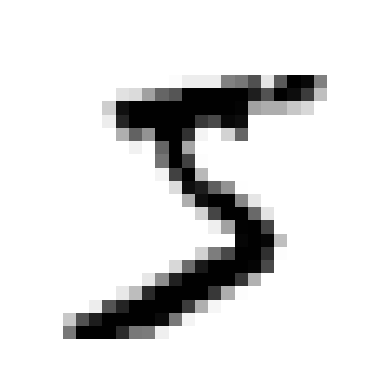

In [6]:
import matplotlib.pyplot as plt

def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = 'binary')
    plt.axis('off')

some_digit = X[0]
plot_digit(some_digit)
plt.show()

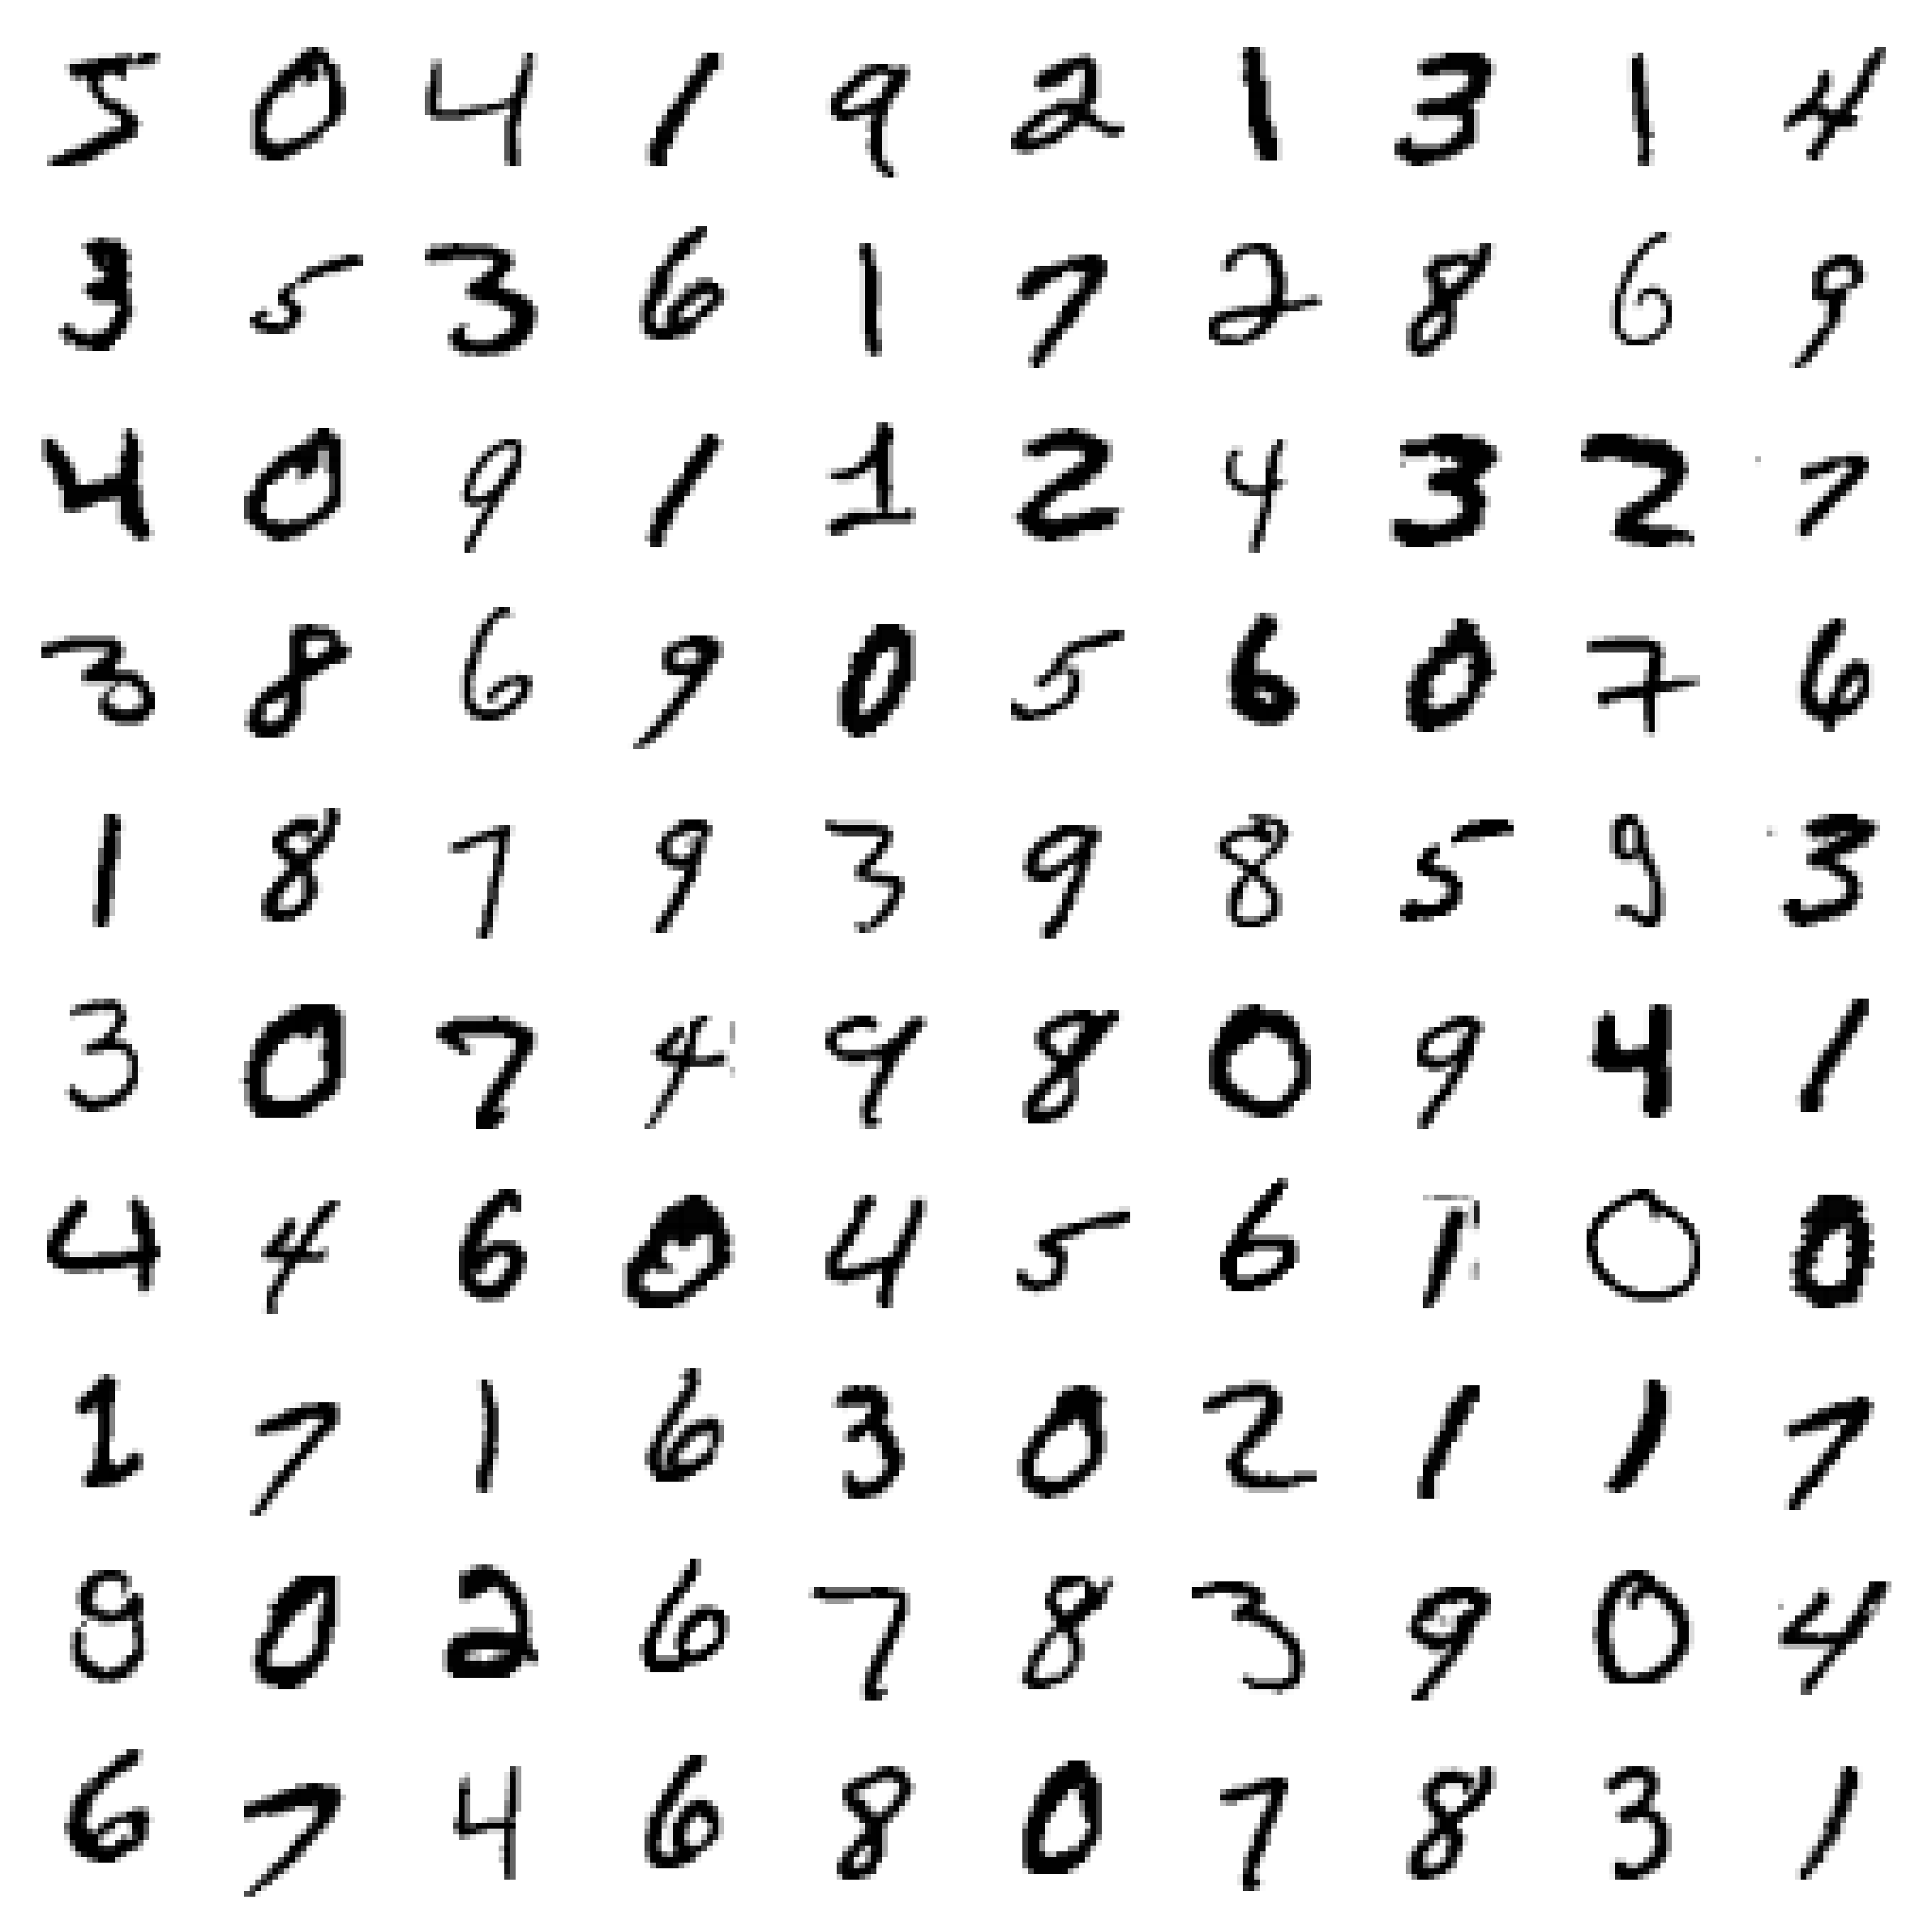

In [7]:
plt.figure(figsize=(10, 10), dpi=300)

for idx, data in enumerate(X[:100]):
    plt.subplot(10, 10, idx+1)
    plot_digit(data)

plt.show()

**Split the data into train and test set**

The training set is already shuffled for us, which is good because this guarantees that all cross-validation folds will be similar (we don’t want one fold to be missing some digits).

In [8]:
X_train, X_test, y_train, y_test  = X[:60000], X[60000:], y[:60000], y[60000:]

In [9]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

### Binary Classifier

Let us train this binary classifier with SGD (Stochastic Gradient Descent)

In [10]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5) # you should not use the test set here because the test set will only be used for model performance

SGDClassifier(random_state=42)

In [11]:
sgd_clf.predict([data for data in X[:100]])

array([ True, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False])

### Performance Measures

In [12]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring='accuracy')

array([0.87365, 0.85835, 0.8689 ])

Above 95% accuracy (ratio of correct predictions) on all cross-validation folds.

In [13]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)

DummyClassifier()

In [14]:
print(any(dummy_clf.predict(X_train)))

False


In [15]:
cross_val_score(dummy_clf, X_train, y_train_5, scoring='accuracy', cv=3)

array([0.90965, 0.90965, 0.90965])

This demonstrates why accuracy is generally not the preferred performance measure for classifiers, especially when you are dealing with skewed datasets. A much better way to evaluate performance of a classifier is to look at the confusion matrix (CM).

#### Implementing our own Cross-validation
Occasionally you will need more control over the cross-validation process than what Scikit-Learn provides off the shelf. In these cases, you can implement cross-validation yourself

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

sk_fold  = StratifiedKFold(n_splits=3) # we add shuffle=True if the dataset is not yet shuffled

# sk_fold.split(X_train, y_train_5) splits both X_train and y_train according to indices
results = []
for train_idx, test_idx in sk_fold.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_idx]
    X_test_folds = X_train[test_idx]
    y_train_folds = y_train_5[train_idx]
    y_test_folds = y_train_5[test_idx]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_folds)
    n_correct_prediction = sum(y_pred == y_test_folds)
    results.append(n_correct_prediction/len(y_pred))

print(results)
    

[0.95035, 0.96035, 0.9604]


In [17]:
sk_fold

StratifiedKFold(n_splits=3, random_state=None, shuffle=False)

### Confusion Matrices
The general idea of a confusion matrix is to count the number of times instances of class A are classified as class B, for all A/B pairs. For example, to know the number of times the classifier confused images of 8s with 0s, you would look at row #8, column #0 of the confusion matrix.

In [18]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [19]:
y_train_pred

array([ True, False, False, ...,  True, False, False])

In [20]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

### Precision and Recall

In [21]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred) # order matters here, so it needs the truth first (y_train_5) 
# precision = TP / (TP+FP)

0.8370879772350012

In [22]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [23]:
print(3530 / (1891 + 3530))

0.6511713705958311


In [24]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [25]:
# get the score
y_scores = sgd_clf.decision_function([data for data in X[:100]])
threshold=3000
y_some_digit_pred = (y_scores > threshold)

y_some_digit_pred.reshape(10,10)

array([[False, False, False, False, False, False, False, False, False,
        False],
       [False,  True, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False,  True, False, False, False,
        False],
       [False, False, False, False, False, False, False,  True, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False,  True, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False]])

### Deciding which threshold to use

In [26]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function')

In [27]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [28]:
precisions[-1]

1.0

In [29]:
thresholds

array([-146348.56726174, -142300.00705404, -137588.97581744, ...,
         38871.26391927,   42216.05562787,   49441.43765905])

In [30]:
import pandas as pd

In [31]:
metrics_df = pd.DataFrame({'recalls' : recalls[:-1], 'precisions' : precisions[:-1], 'thresholds' : thresholds})
metrics_df.head()

,recalls,precisions,thresholds
0,1.0,0.090350,-146348.567262
1,1.0,0.090352,-142300.007054
2,1.0,0.090353,-137588.975817
3,1.0,0.090355,-137155.626441
4,1.0,0.090356,-136254.058562


In [32]:
metrics_df.sort_values(by='precisions', inplace=True, ascending=True)
metrics_df.loc[metrics_df['precisions'] >= 0.90]

,recalls,precisions,thresholds
59920,0.013282,0.900000,24714.048854
57110,0.479801,0.900000,3370.069204
57109,0.479985,0.900035,3370.019499
57116,0.478878,0.900139,3385.441464
57115,0.479063,0.900173,3384.997798
...,...,...,...
59997,0.000553,1.000000,38871.263919
59998,0.000369,1.000000,42216.055628
59995,0.000922,1.000000,36801.606970
59996,0.000738,1.000000,37026.251165


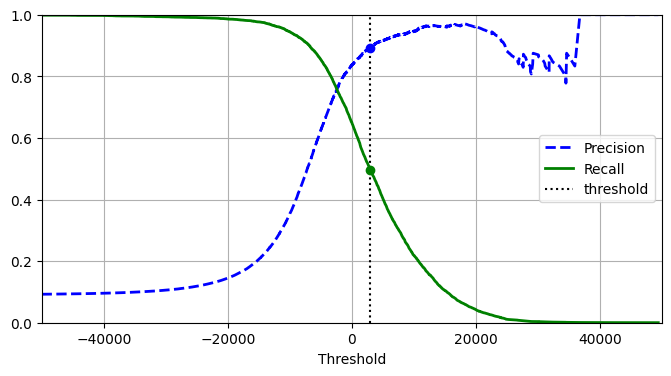

In [33]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")

plt.show()

**Plotting recall agains precision**

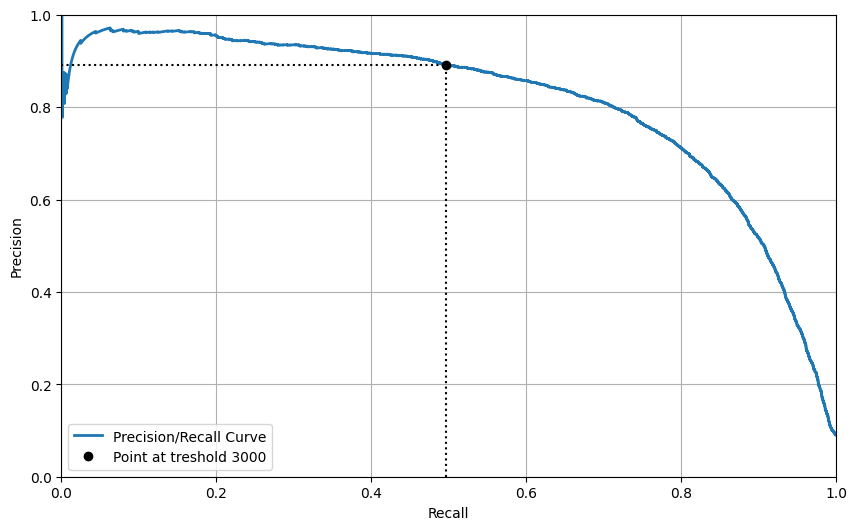

In [34]:
plt.figure(figsize=(10,6), dpi=100)
plt.plot(recalls, precisions, linewidth=2.0, label = 'Precision/Recall Curve')
plt.plot([recalls[idx], recalls[idx]], [0, precisions[idx]], 'k:')
plt.plot([0, recalls[idx]], [precisions[idx], precisions[idx]], 'k:')
plt.plot([recalls[idx]], [precisions[idx]], 'ko', label = 'Point at treshold 3000')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')
plt.axis([0, 1, 0, 1])
plt.grid()

In [35]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

3370.019499144183

In [36]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
y_train_pred_90

array([False, False, False, ...,  True, False, False])

In [37]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [38]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

### ROC Curve
The receiver operating characteristic (ROC) curve is another common tool used with binary classifiers. It is very similar to the precision/recall curve, but instead of plotting precision versus recall, the ROC curve plots the true positive rate (another name for recall) against the false positive rate (FPR).

In [39]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds  = roc_curve(y_train_5, y_scores)

In [40]:
fpr_tpr_thresholds_df = pd.DataFrame({'fpr' : fpr, 'tpr' : tpr, 'thresholds' : thresholds})
fpr_tpr_thresholds_df.head(10)

,fpr,tpr,thresholds
0,0.000000,0.000000,inf
1,0.000000,0.000184,4.944144e+04
2,0.000000,0.000922,3.680161e+04
3,0.000018,0.000922,3.598720e+04
4,0.000018,0.001291,3.466221e+04
5,0.000037,0.001291,3.454745e+04
6,0.000037,0.002398,3.184789e+04
7,0.000055,0.002398,3.183959e+04
8,0.000055,0.003874,2.926419e+04
9,0.000092,0.003874,2.897037e+04


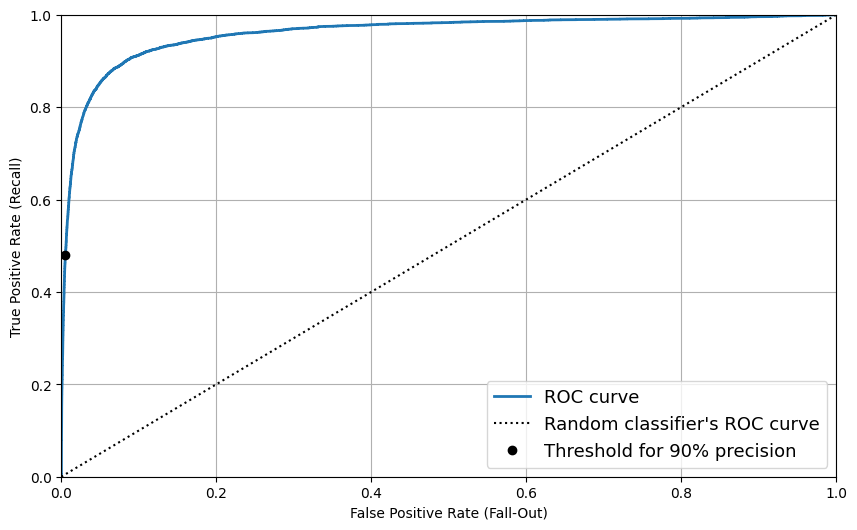

In [41]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(10, 6), dpi=100)  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# extra code – just beautifies and saves Figure 3–7
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

One way to compute classifeier is to measure the aread under the curve (AUC). A perfect classifier will have a ROC AUC equal to 1, whereas a purely random classifier will have a ROC AUC equal to 0.5.

In [42]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

0.9604938554008616

### Random Forest Classifier

In [43]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)

In [44]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method='predict_proba')

In [45]:
y_probas_forest[:10]

# The model predicts that the first image is positive with 89% probability, and it predicts that the second image is negative with 99% probability.

array([[0.11, 0.89],
       [0.98, 0.02],
       [0.96, 0.04],
       [1.  , 0.  ],
       [0.99, 0.01],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.99, 0.01]])

In [46]:
y_scores_forest = y_probas_forest[:, 1]

precisions_forest, recalls_forest, threshold_forest = precision_recall_curve(y_train_5, y_scores_forest)

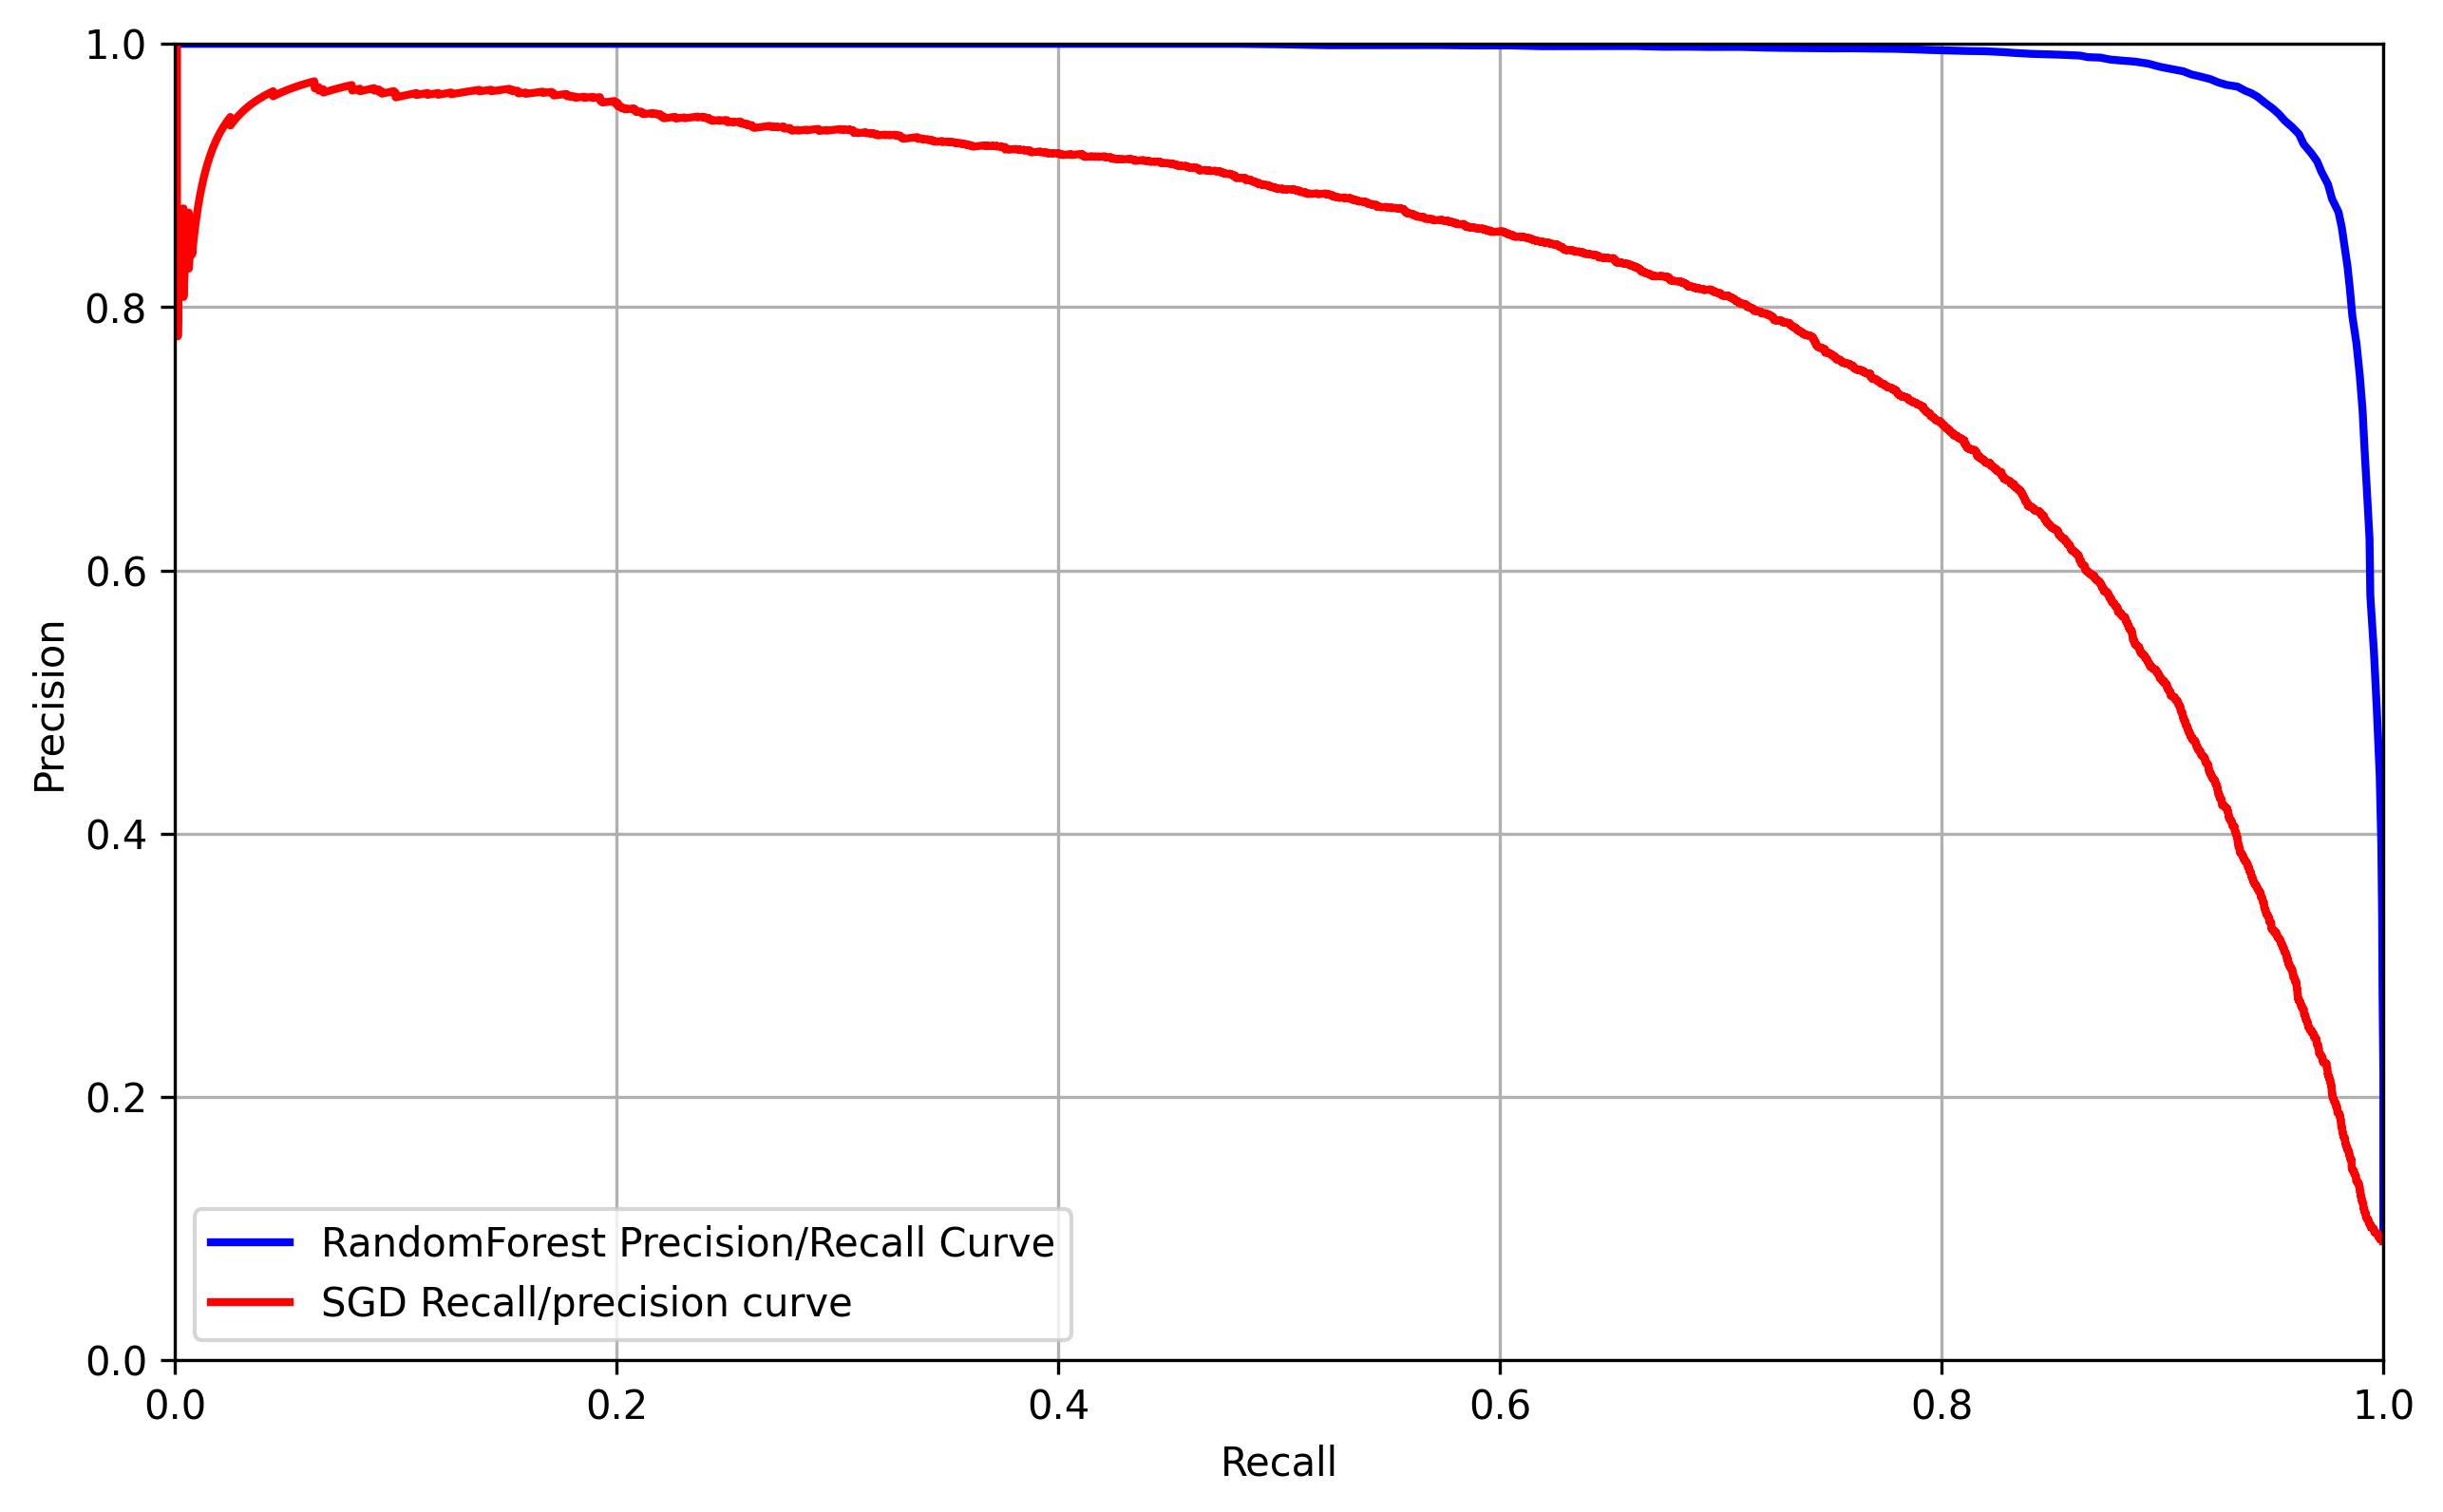

In [47]:
plt.figure(figsize = (10,6), dpi=300)
plt.plot(recalls_forest, precisions_forest, 'b', linewidth=2, label='RandomForest Precision/Recall Curve')
plt.plot(recalls, precisions, 'r', linewidth=2, label='SGD Recall/precision curve')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc='lower left')
plt.show()

The RandomForestClassifier’s PR curve looks much better than the SGDClassifier’s: it comes much closer to the top-right corner

In [48]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5
f1_score(y_train_5, y_train_pred_forest)

0.9270445185330457

In [49]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983296721818179

In [50]:
recall_score(y_train_5, y_train_pred_forest)

0.8719793396052389

In [51]:
precision_score(y_train_5, y_train_pred_forest)

0.9895331798199707

## Multiclass Classification

SVMs do not scale well to large datasets, so let's only train on the first 2,000 instances, or else this section will take a very long time to run:

In [52]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

SVC(random_state=42)

In [53]:
y_train_pred = cross_val_predict(svm_clf, X_train[:2000], y_train[:2000], cv=3)

In [54]:
cm = confusion_matrix(y_train[:2000], y_train_pred)
cm

array([[182,   0,   1,   2,   0,   3,   2,   0,   1,   0],
       [  0, 210,   1,   1,   1,   2,   0,   1,   4,   0],
       [  0,   3, 181,   1,   4,   1,   0,   6,   2,   0],
       [  1,   1,   2, 168,   0,  12,   1,   2,   2,   2],
       [  1,   1,   3,   0, 201,   0,   3,   1,   0,   4],
       [  0,   0,   2,   5,   3, 163,   3,   0,   2,   2],
       [  2,   1,   2,   0,   3,   3, 189,   0,   0,   0],
       [  1,   4,   1,   1,  10,   0,   0, 202,   0,   5],
       [  0,   5,   4,   1,   0,   1,   2,   1, 156,   2],
       [  3,   0,   0,   3,   9,   1,   0,   8,   2, 184]])

In [55]:
some_digit_scores = svm_clf.decision_function(X[:2]).round(2)
some_digit_scores

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82],
       [ 9.31, -0.29,  6.14,  7.21,  0.71,  8.28,  3.8 ,  1.77,  2.77,
         5.11]])

In [56]:
# Check what the classes are
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

### OneVsOneClassifieer, OneVsRestClassifier

In [57]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

OneVsRestClassifier(estimator=SVC(random_state=42))

In [58]:
ovr_clf.predict([X[0]])

array(['5'], dtype='<U1')

In [59]:
ovr_clf.estimators_

[SVC(random_state=42),
 SVC(random_state=42),
 SVC(random_state=42),
 SVC(random_state=42),
 SVC(random_state=42),
 SVC(random_state=42),
 SVC(random_state=42),
 SVC(random_state=42),
 SVC(random_state=42),
 SVC(random_state=42)]

### SGD Classifier as Multi Classification

In [60]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)

SGDClassifier(random_state=42)

In [61]:
sgd_clf.predict([X[0]])

array(['3'], dtype='<U1')

In [62]:
sgd_clf.decision_function([X[0]])

array([[-31893.03095419, -34419.69069632,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

In [63]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring='accuracy')

array([0.87365, 0.85835, 0.8689 ])

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype('float64'))

In [65]:
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring='accuracy')

array([0.8983, 0.891 , 0.9018])

In [66]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)

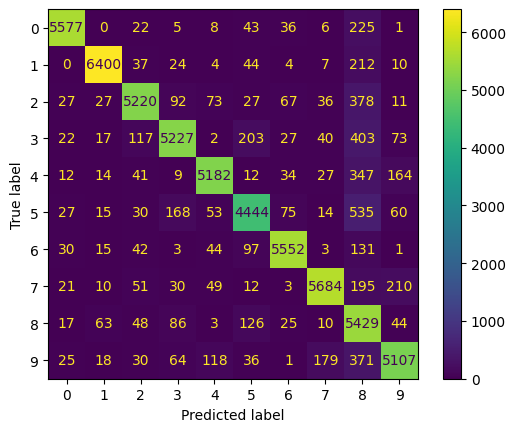

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

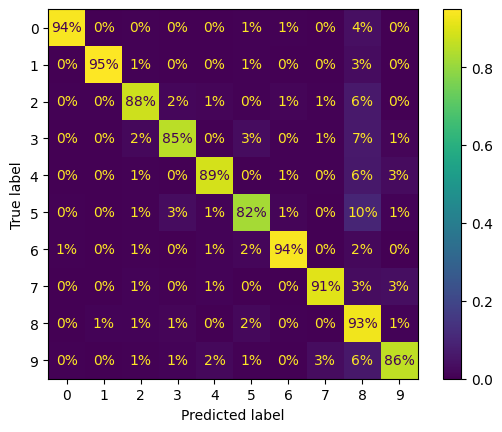

In [68]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize='true', values_format=".0%")
plt.show()

In [69]:
sample_weight = (y_train_pred != y_train)

The 36% in row #7, column #9 does not mean that 36% of all images of 7s were misclassified as 9s. It means that 36% of the errors the model made on images of 7s were misclassifications as 9s.

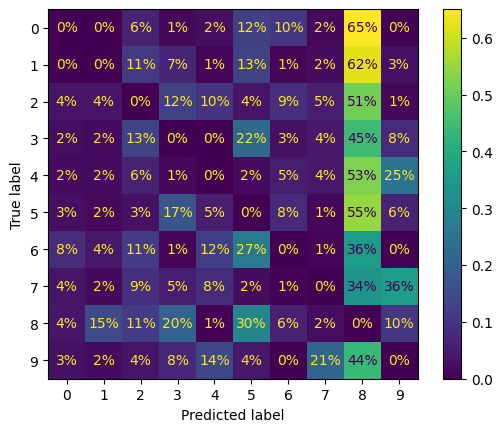

In [70]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight=sample_weight, normalize='true', values_format='.0%')

# most of the errors for classifying 0 were mistakenly classified as 8
# the confusion matrix shows the error row-wise (summing all the values in this row is 1)
# in classifying 1, 62% were 8
# 65% of the misclassified 0s were wrongly predicted as 8.

56% of misclassified 7s are actually 9s.

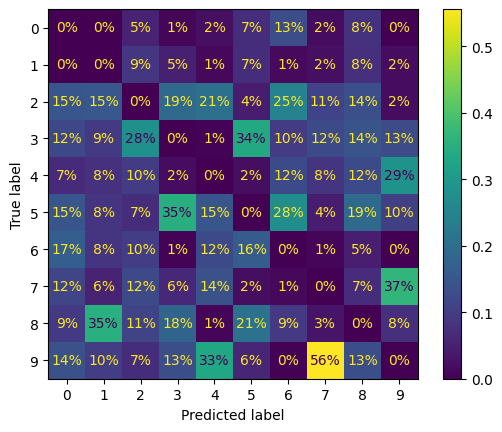

In [71]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight=sample_weight, normalize='pred', values_format='.0%')

# 8% of 8's were mistakenly classified as 0 and 1
# 56% from class 9
# 28% from class 5
# 13% from class 4
# 3% from class 8

In [72]:
cl_a, cl_b = '3', '5'

X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]

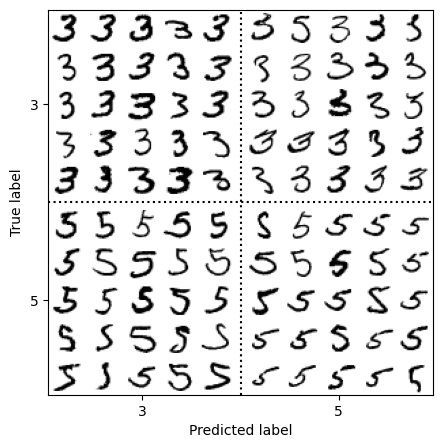

In [73]:
# extra code – this cell generates and saves Figure 3–11
size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y, y + 1))
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

### Multilabel Classification

In [74]:
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')

In [75]:
y_train_large

array([False, False, False, ..., False, False,  True])

In [76]:
import numpy as np

In [77]:
y_train_odd = (y_train.astype('int64') % 2 != 0)
y_multilabel = np.c_[y_train_large, y_train_odd]
# np.c_ is used for concatenation of arrays

In [78]:
y_multilabel

array([[False,  True],
       [False, False],
       [False, False],
       ...,
       [False,  True],
       [False, False],
       [ True, False]])

In [79]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

In [80]:
# predicting the first 10 numbers
knn_clf.predict(X[:10])

array([[False,  True],
       [False, False],
       [False, False],
       [False,  True],
       [ True,  True],
       [False, False],
       [False,  True],
       [False,  True],
       [False,  True],
       [False, False]])

In [81]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average = 'macro')

0.9764102655606048

### Chain Classifier

In [82]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

ClassifierChain(base_estimator=SVC(), cv=3, random_state=42)

In [83]:
chain_clf.predict(X[:1])

array([[0., 1.]])

## Multioutput Classification
It is a generalization of multilabel classification where each label can be multiclass (i.e., it can have more than two possible values).

In [84]:
np.random.seed(42)  # to make this code example reproducible
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

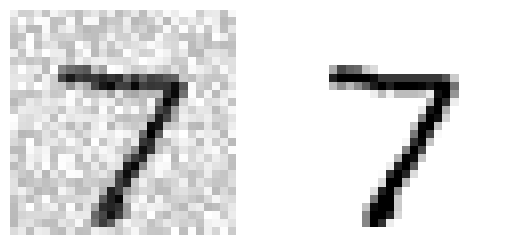

In [85]:
plt.subplot(121); plot_digit(X_test_mod[0])
plt.subplot(122); plot_digit(y_test_mod[0])
plt.show()

In [86]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)

KNeighborsClassifier()

In [87]:
clean_digit = knn_clf.predict(X_test_mod[:1])

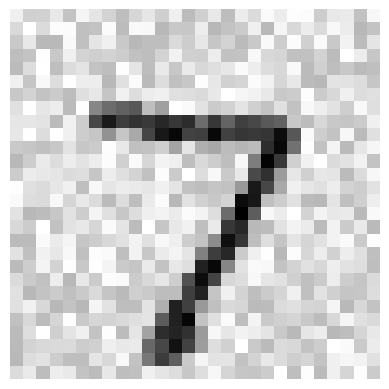

In [88]:
plot_digit(X_test_mod[:1])

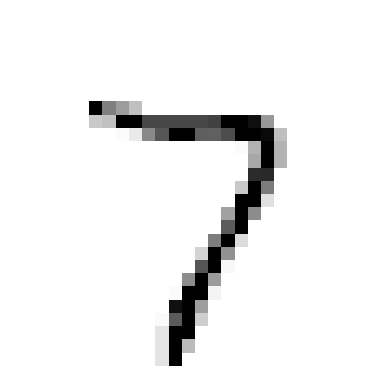

In [89]:
plot_digit(clean_digit)

# Exercises

1. Try to build a classifier for the MNIST dataset that achieves over 97% accuracy on the test set. Hint: the `KNeighborsClassifier` works quite well for this task; you just need to find good hyperparameter values (try a grid search on the `weights` and `n_neighbors` hyperparameters).

In [90]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline

In [91]:
X_train = X_train.copy()
y_train = y_train.copy()
X_test = X_test.copy()
y_test = y_test.copy()

In [92]:
# Simple KNeighborsClassifier
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)

KNeighborsClassifier()

In [93]:
baseline_accuracy = knn_clf.score(X_test, y_test)
baseline_accuracy

0.9688

In [94]:
k_neighbors = KNeighborsClassifier()
full_pipeline = Pipeline([
    ('knn', k_neighbors)
])

param_grid = [
    {'knn__weights' : ['uniform', 'distance'],
     'knn__n_neighbors' : [3, 4, 5, 6, 7, 8, 9, 10]}
]

grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=Pipeline(steps=[('knn', KNeighborsClassifier())]),
             param_grid=[{'knn__n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10],
                          'knn__weights': ['uniform', 'distance']}],
             scoring='accuracy')

In [95]:
grid_search.best_params_

{'knn__n_neighbors': 4, 'knn__weights': 'distance'}

In [96]:
grid_search.score(X_test, y_test)

0.9714

**Inference**

We achieve a 97% accuracy!

2. Write a function that can shift an MNIST image in any direction (left, right, up, or down) by one pixel. You can use the `shift()` function from the `scipy.ndimage` module. For example, `shift(image, [2, 1], cval=0)` shifts the image two pixels down and one pixel to the right. Then, for each image in the training set, create four shifted copies (one per direction) and add them to the training set. Finally, train your best model on this expanded training set and measure its accuracy on the test set. You should observe that your model performs even better now! This technique of artificially growing the training set is called _data augmentation_ or _training set expansion.

In [97]:
y_train

array(['5', '0', '4', ..., '5', '6', '8'], dtype=object)

In [98]:
def shift_image(image):
    reshaped_image = image.reshape(28, 28)

    # shift above
    above = reshaped_image.copy()
    above[:-1] = above[1:]
    above[-1] = above[-1] * 0
    
    # shift below
    below = reshaped_image.copy()
    below[1:] = below[:-1]
    below[0] = below[0]*0

    # shift to the right
    right = reshaped_image.copy()
    right[:, 1:] = right[:, :-1]
    right[:, 0] = right[:, 0] * 0

    # shift to the left
    left = reshaped_image.copy()
    left[:, :-1] = left[:, 1:]
    left[:, -1] = left[:, -1]*0

    return above.reshape(784), below.reshape(784), right.reshape(784), left.reshape(784)

aug_rows = [X_train]
y_aug = [y_train]
for image, label in zip(X_train, y_train):
    above, below, right, left = shift_image(image)
    aug_rows.extend([above, below, right, left])
    y_aug.extend([np.array([label]), np.array([label]),
                  np.array([label]), np.array([label])])

X_train = np.vstack(aug_rows)
y_train = np.concatenate(y_aug)


In [99]:
grid_search.best_estimator_.fit(X_train, y_train)

Pipeline(steps=[('knn',
                 KNeighborsClassifier(n_neighbors=4, weights='distance'))])

In [100]:
data_augmented_tuned = grid_search.score(X_test, y_test)

In [101]:
data_augmented_tuned

0.9763

3. Tackle the Titanic dataset. A great place to start is on [Kaggle](https://www.kaggle.com/c/titanic). Alternatively, you can download the data from https://homl.info/titanic.tgz and unzip this tarball like you did for the housing data in Chapter 2. This will give you two CSV files: _train.csv_ and _test.csv_ which you can load using `pandas.read_csv()`. The goal is to train a classifier that can predict the `Survived` column based on the other columns.

In [102]:
import pandas as pd

train = pd.read_csv('datasets/titanic/train.csv')
X_test = pd.read_csv('datasets/titanic/test.csv')

X_train, y_train = train.drop(columns='Survived'), train[['Survived']]

In [103]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Exploratory Data Analysis

In [106]:
df = X_train.copy()

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    object 
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB
